# 2. Which subscribers churn, and are newer ones worse?

Questions 3 and 4 of the project ([questions](../docs/questions.md)), plus
the check that matters most for the recommendation: is it the person or the
payment setup?

The unit is a **renewal decision**: every time a paid period ends, the
subscriber either pays again or leaves (`core.renewals`).

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.ticker as mticker
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display

import charts
from analysis import connect

charts.use_style()
pd.set_option("display.max_columns", 20)
con = connect()

## Q3. Churn by segment, 2016 renewal decisions

In [2]:
con.sql("""
    CREATE TEMP TABLE d AS
    SELECT
        r.churned::INT AS churned,
        r.is_auto_renew,
        r.is_discounted,
        r.started_with_trial,
        r.paid_number > 1 AS returning_sub,
        u.channel,
        u.registered_in_window,
        CASE WHEN r.plan_days <= 31 THEN 'monthly'
             WHEN r.plan_days < 360 THEN '3-6 months' ELSE '12+ months' END AS plan,
        CASE WHEN r.payment_number = 1 THEN '1' WHEN r.payment_number = 2 THEN '2'
             WHEN r.payment_number = 3 THEN '3' WHEN r.payment_number <= 6 THEN '4-6'
             WHEN r.payment_number <= 12 THEN '7-12' ELSE '13+' END AS tenure,
        CASE WHEN r.payment_method_id IN (41, 40, 39, 38, 37, 36, 34, 33, 32, 31)
             THEN 'pm ' || r.payment_method_id ELSE 'pm other' END AS pm
    FROM core.renewals AS r
    JOIN core.users AS u USING (user_id)
    WHERE r.period_end BETWEEN DATE '2016-01-01' AND DATE '2016-12-31'
""")
n, base = con.sql("SELECT count(*), avg(churned) FROM d").fetchone()
print(f"{n:,} renewal decisions in 2016; {100 * base:.2f}% ended in churn")

for col in ["is_auto_renew", "tenure", "plan", "started_with_trial", "channel", "pm"]:
    display(con.sql(f"""
        SELECT {col} AS level, count(*) AS decisions,
               round(100.0 * count(*) / {n}, 1) AS pct_of_decisions,
               round(100 * avg(churned), 2) AS churn_pct
        FROM d GROUP BY 1 ORDER BY decisions DESC
    """).df().rename(columns={"level": col}))

10,151,119 renewal decisions in 2016; 4.56% ended in churn


,is_auto_renew,decisions,pct_of_decisions,churn_pct
0,True,8801865,86.7,2.26
1,False,1349254,13.3,19.57


,tenure,decisions,pct_of_decisions,churn_pct
0,13+,4099426,40.4,2.25
1,7-12,2774141,27.3,2.66
2,4-6,1405726,13.8,3.55
3,1,747607,7.4,21.20
4,2,585767,5.8,9.41
5,3,538452,5.3,6.14


,plan,decisions,pct_of_decisions,churn_pct
0,monthly,9948321,98.0,4.06
1,3-6 months,132002,1.3,26.92
2,12+ months,70796,0.7,32.46


,started_with_trial,decisions,pct_of_decisions,churn_pct
0,False,10095409,99.5,4.50
1,True,55710,0.5,14.56


,channel,decisions,pct_of_decisions,churn_pct
0,channel 7,4959124,48.9,1.59
1,channel 9,2600401,25.6,6.61
2,unknown,1167010,11.5,4.67
3,channel 3,1096026,10.8,9.88
4,channel 4,324834,3.2,15.10
5,other,3724,0.0,4.89


,pm,decisions,pct_of_decisions,churn_pct
0,pm 41,5898662,58.1,1.91
1,pm 40,924044,9.1,3.09
2,pm 38,813967,8.0,18.42
3,pm 36,465531,4.6,10.99
4,pm 39,457013,4.5,5.26
5,pm 37,454408,4.5,2.15
6,pm 34,385164,3.8,0.96
7,pm other,313953,3.1,16.02
8,pm 33,207829,2.0,2.32
9,pm 31,133118,1.3,1.07


In [3]:
shares = con.sql("""
    SELECT
        100 * avg((NOT is_auto_renew)::INT) AS manual_share_of_decisions,
        100.0 * sum(churned * (NOT is_auto_renew)::INT) / sum(churned) AS manual_share_of_churn,
        100 * avg((tenure = '1')::INT) AS first_renewal_share_of_decisions,
        100.0 * sum(churned * (tenure = '1')::INT) / sum(churned) AS first_renewal_share_of_churn,
        100 * avg((tenure = '1' AND NOT is_auto_renew)::INT) AS manual_first_share_of_decisions,
        100.0 * sum(churned * (tenure = '1' AND NOT is_auto_renew)::INT) / sum(churned) AS manual_first_share_of_churn
    FROM d
""").df().round(1)
display(shares.T)

,0
manual_share_of_decisions,13.3
manual_share_of_churn,57.1
first_renewal_share_of_decisions,7.4
first_renewal_share_of_churn,34.2
manual_first_share_of_decisions,3.5
manual_first_share_of_churn,28.3


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/02_manual_share.png')

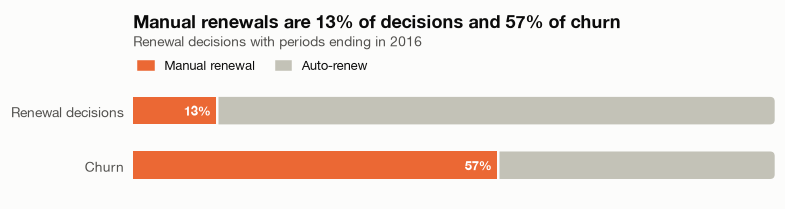

In [4]:
m_dec, m_churn = shares.manual_share_of_decisions[0], shares.manual_share_of_churn[0]
fig, ax = charts.figure(height=2.6, bottom=0.2, top=0.62, left=0.16)
ax.set_xlim(0, 100)
ax.set_ylim(-0.6, 1.6)
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.set_xticks([])
for y, manual in [(1, m_dec), (0, m_churn)]:
    charts.stacked_hbar(ax, y, [manual, 100 - manual], [charts.ORANGE, charts.GRAY])
    charts.note(ax, manual - 1.2, y, f"{manual:.0f}%", ha="right", color="#ffffff", fontweight="bold")
ax.set_yticks([1, 0])
ax.set_yticklabels(["Renewal decisions", "Churn"], color=charts.INK_2, fontsize=9)
from matplotlib.patches import Patch
charts.legend(ax, [(Patch(color=charts.ORANGE), "Manual renewal"), (Patch(color=charts.GRAY), "Auto-renew")], y=1.0)
charts.titles(fig, ax, f"Manual renewals are {m_dec:.0f}% of decisions and {m_churn:.0f}% of churn",
              "Renewal decisions with periods ending in 2016")
charts.save(fig, "02_manual_share.png")

### Separating the overlaps

Manual payers are more often new, on long plans, or from channels 3, 4 and 9.
A logistic regression on a random sample of 600k decisions separates the
factors. "Adjusted" is the predicted churn rate with the factor set to that
level for everyone and all other factors left at their real mix.

In [5]:
con.execute("SET threads = 1")  # makes the seeded sample reproducible
sample = con.sql("SELECT * FROM d USING SAMPLE reservoir(600000 ROWS) REPEATABLE (42)").df()
con.execute("RESET threads")
for c in ["is_auto_renew", "returning_sub", "started_with_trial", "is_discounted", "registered_in_window"]:
    sample[c] = sample[c].astype(int)

model = smf.logit(
    "churned ~ is_auto_renew + C(pm, Treatment('pm 41')) + C(plan, Treatment('monthly'))"
    " + C(tenure, Treatment('13+')) + returning_sub + started_with_trial + is_discounted"
    " + C(channel, Treatment('channel 7')) + registered_in_window",
    data=sample,
).fit(disp=False, maxiter=200)
print(f"pseudo R² {model.prsquared:.3f}")


def adjusted(col, level):
    x = sample.copy()
    x[col] = level
    return 100 * model.predict(x).mean()


rows = []
for factor, col, levels in [
    ("Payment", "is_auto_renew", [(1, "Auto-renew"), (0, "Manual")]),
    ("Tenure", "tenure", [("1", "1st payment"), ("2", "2nd"), ("3", "3rd"), ("4-6", "4th–6th"),
                          ("7-12", "7th–12th"), ("13+", "13th+")]),
    ("Plan", "plan", [("monthly", "Monthly"), ("3-6 months", "3–6 months"), ("12+ months", "12+ months")]),
    ("Free trial start", "started_with_trial", [(0, "No"), (1, "Yes")]),
    ("Returning subscriber", "returning_sub", [(0, "No"), (1, "Yes")]),
    ("Channel", "channel", [("channel 7", "Channel 7"), ("channel 9", "Channel 9"),
                            ("channel 3", "Channel 3"), ("channel 4", "Channel 4")]),
]:
    for level, label in levels:
        rows.append({"factor": factor, "level": label,
                     "raw_pct": 100 * sample.loc[sample[col] == level, "churned"].mean(),
                     "adjusted_pct": adjusted(col, level)})
adj = pd.DataFrame(rows).round(2)
display(adj)

pseudo R² 0.199


,factor,level,raw_pct,adjusted_pct
0,Payment,Auto-renew,2.24,2.61
1,Payment,Manual,19.64,11.09
2,Tenure,1st payment,21.62,10.98
3,Tenure,2nd,9.28,5.79
4,Tenure,3rd,5.99,4.41
5,Tenure,4th–6th,3.56,3.27
6,Tenure,7th–12th,2.63,3.03
7,Tenure,13th+,2.23,3.18
8,Plan,Monthly,4.06,4.48
9,Plan,3–6 months,27.33,5.53


/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/src/charts.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.savefig(IMG_DIR / name, bbox_inches="tight", pad_inches=0.12)


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/02_raw_vs_adjusted.png')

/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/.venv/lib/python3.13/site-packages/IPython/core/events.py:101: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  func(*args, **kwargs)
/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)


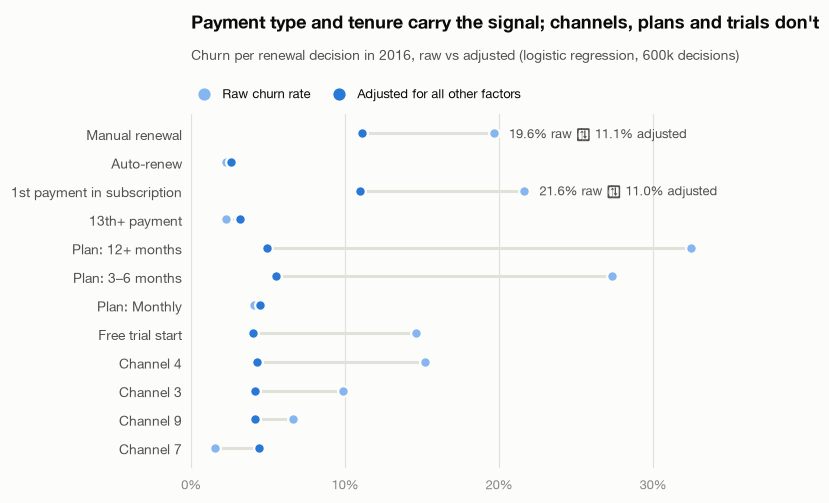

In [6]:
show = adj[adj.level.isin(["Manual", "Auto-renew", "1st payment", "13th+", "12+ months", "3–6 months",
                           "Monthly", "Channel 4", "Channel 3", "Channel 9", "Channel 7"])
           | ((adj.factor == "Free trial start") & (adj.level == "Yes"))].copy()
show["label"] = show.apply(lambda r: "Free trial start" if r.factor == "Free trial start"
                           else ("Plan: " + r.level if r.factor == "Plan" else
                                 ("Payment " + r.level.lower() if r.level == "13th+" or r.level == "1st payment" else r.level)), axis=1)
order = ["Manual", "Auto-renew", "Payment 1st payment", "Payment 13th+", "Plan: 12+ months",
         "Plan: 3–6 months", "Plan: Monthly", "Free trial start", "Channel 4", "Channel 3", "Channel 9", "Channel 7"]
show = show.set_index("label").loc[order].reset_index()
show["label"] = show.label.replace({"Payment 1st payment": "1st payment in subscription",
                                    "Payment 13th+": "13th+ payment", "Manual": "Manual renewal"})

fig, ax = charts.figure(height=4.6, left=0.27, bottom=0.1, top=0.8)
ys = list(range(len(show)))[::-1]
ax.set_ylim(-0.7, len(show) - 0.3)
ax.set_xlim(0, 36)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["bottom"].set_visible(False)
for y, (_, r) in zip(ys, show.iterrows()):
    ax.plot([r.raw_pct, r.adjusted_pct], [y, y], color=charts.GRID, linewidth=2, zorder=1, solid_capstyle="round")
    ax.plot(r.raw_pct, y, "o", markersize=7, color=charts.BLUE_LIGHT, markeredgecolor=charts.SURFACE, markeredgewidth=1.5, zorder=3)
    ax.plot(r.adjusted_pct, y, "o", markersize=7, color=charts.BLUE, markeredgecolor=charts.SURFACE, markeredgewidth=1.5, zorder=4)
for i in [0, 2]:  # label the two rows the story is about
    r = show.iloc[i]
    charts.note(ax, max(r.raw_pct, r.adjusted_pct) + 1, ys[i], f"{r.raw_pct:.1f}% raw → {r.adjusted_pct:.1f}% adjusted")
ax.set_yticks(ys)
ax.set_yticklabels(show.label, color=charts.INK_2, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
from matplotlib.lines import Line2D
dot = lambda c: Line2D([], [], marker="o", linestyle="", markersize=7, color=c)
charts.legend(ax, [(dot(charts.BLUE_LIGHT), "Raw churn rate"), (dot(charts.BLUE), "Adjusted for all other factors")])
charts.titles(fig, ax, "Payment type and tenure carry the signal; channels, plans and trials don't",
              "Churn per renewal decision in 2016, raw vs adjusted (logistic regression, 600k decisions)")
charts.save(fig, "02_raw_vs_adjusted.png")

### Is it the person or the payment setup?

Monthly subscriptions that started with two payments on the same setup: what
happened after the third payment changed it, or didn't? Third payments with
periods ending March 2015 – September 2016, so the next two outcomes are known.

In [7]:
con.sql("""
    CREATE TEMP TABLE p AS
    SELECT user_id, subscription_number,
        max(CASE WHEN payment_number = 1 THEN is_auto_renew::INT END) AS a1,
        max(CASE WHEN payment_number = 2 THEN is_auto_renew::INT END) AS a2,
        max(CASE WHEN payment_number = 3 THEN is_auto_renew::INT END) AS a3,
        max(CASE WHEN payment_number = 3 THEN transaction_date END) AS tx3,
        max(CASE WHEN payment_number = 3 THEN period_end END) AS end3,
        max(CASE WHEN payment_number = 3 THEN churned::INT END) AS churn3,
        max(CASE WHEN payment_number = 4 THEN churned::INT END) AS churn4,
        max(CASE WHEN payment_number = 5 THEN churned::INT END) AS churn5,
        max(CASE WHEN payment_number = 2 THEN payment_method_id END) AS pm2,
        max(CASE WHEN payment_number = 3 THEN payment_method_id END) AS pm3,
        max(plan_days) FILTER (WHERE payment_number <= 5) AS max_plan
    FROM core.renewals
    GROUP BY 1, 2
""")
con.sql("""
    CREATE TEMP TABLE sw AS
    SELECT p.*,
        CASE WHEN a1 = 0 AND a3 = 1 THEN 'Manual, then switched to auto-renew'
             WHEN a1 = 0 AND a3 = 0 THEN 'Manual, stayed manual'
             WHEN a1 = 1 AND a3 = 0 THEN 'Auto-renew, then switched to manual'
             ELSE 'Auto-renew, stayed on auto-renew' END AS grp,
        (coalesce(churn3, 0) + coalesce(churn4, 0) + coalesce(churn5, 0) > 0)::INT AS churned_by_5,
        (SELECT coalesce(sum(w.active_days), 0) FROM core.user_weeks AS w
          WHERE w.user_id = p.user_id AND w.week >= p.tx3 - 34 AND w.week + 6 < p.tx3) AS days_before
    FROM p
    WHERE a3 IS NOT NULL AND a1 = a2 AND max_plan <= 31
      AND end3 BETWEEN DATE '2015-03-01' AND DATE '2016-09-30'
""")
switch = con.sql("""
    SELECT grp, count(*) AS subscriptions,
           round(100 * avg(churned_by_5), 1) AS pct_churned_by_5th_payment,
           round(avg(days_before), 1) AS active_days_in_4_weeks_before
    FROM sw GROUP BY 1
""").df().set_index("grp").loc[["Manual, then switched to auto-renew", "Manual, stayed manual",
                               "Auto-renew, then switched to manual", "Auto-renew, stayed on auto-renew"]]
display(switch)
display(con.sql("""
    SELECT CASE WHEN days_before = 0 THEN '0' WHEN days_before <= 7 THEN '1-7'
                WHEN days_before <= 14 THEN '8-14' ELSE '15-28' END AS active_days_before,
           count(*) FILTER (WHERE a3 = 1) AS switched,
           count(*) FILTER (WHERE a3 = 0) AS stayed,
           round(100 * avg(churned_by_5) FILTER (WHERE a3 = 1), 1) AS switched_pct_churned,
           round(100 * avg(churned_by_5) FILTER (WHERE a3 = 0), 1) AS stayed_pct_churned
    FROM sw WHERE a1 = 0 GROUP BY 1 ORDER BY min(days_before)
""").df())
display(con.sql("""
    SELECT count(*) AS switched_on_same_method, round(100 * avg(churned_by_5), 1) AS pct_churned
    FROM sw WHERE a1 = 0 AND a3 = 1 AND pm3 = pm2
""").df())

,subscriptions,pct_churned_by_5th_payment,active_days_in_4_weeks_before
grp,,,
"Manual, then switched to auto-renew",3761,10.2,18.5
"Manual, stayed manual",167986,37.1,19.5
"Auto-renew, then switched to manual",1694,36.5,17.4
"Auto-renew, stayed on auto-renew",921967,5.6,11.7


,active_days_before,switched,stayed,switched_pct_churned,stayed_pct_churned
0,0,49,1726,18.4,60.4
1,1-7,421,15663,15.0,53.6
2,8-14,659,26430,15.2,44.0
3,15-28,2632,124167,8.1,33.2


,switched_on_same_method,pct_churned
0,1281,10.0


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/02_switchers.png')

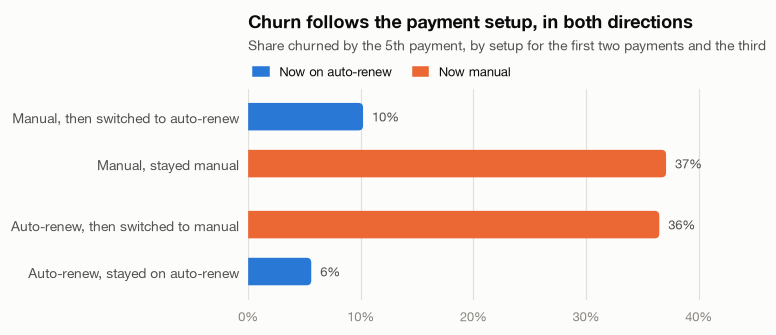

In [8]:
fig, ax = charts.figure(height=3.2, left=0.33, bottom=0.12, top=0.72)
labels = list(switch.index)
vals = switch.pct_churned_by_5th_payment.values
ys = [3.3, 2.3, 1, 0]
ax.set_ylim(-0.6, 3.9)
ax.set_xlim(0, 45)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["bottom"].set_visible(False)
colors = [charts.BLUE, charts.ORANGE, charts.ORANGE, charts.BLUE]
charts.bars(ax, ys, vals, colors, horizontal=True)
for y, v in zip(ys, vals):
    charts.note(ax, v + 0.8, y, f"{v:.0f}%")
ax.set_yticks(ys)
ax.set_yticklabels(labels, color=charts.INK_2, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
charts.legend(ax, [(Patch(color=charts.BLUE), "Now on auto-renew"), (Patch(color=charts.ORANGE), "Now manual")])
charts.titles(fig, ax, "Churn follows the payment setup, in both directions",
              "Share churned by the 5th payment, by setup for the first two payments and the third")
charts.save(fig, "02_switchers.png")

**What it says.** Manual renewals and the first renewal carry most of the churn.
Once those two are known, channel, plan length and free trials add little: the
raw gaps were the same manual payers seen from another angle. People who switch
setup start to churn like the setup they switched to, and the switchers weren't
the keener listeners. It's still observational, which is why the recommendation
comes with a test.

## Q4. Are newer customers worse than older ones?

In [9]:
mix = con.sql("""
    SELECT year(cohort_month) || ' H' || CASE WHEN month(cohort_month) <= 6 THEN 1 ELSE 2 END AS half,
           channel, sum(cohort_users) AS users
    FROM marts.cohort_retention
    WHERE months_since_first_payment = 0
    GROUP BY 1, 2
""").df().pivot_table(index="half", columns="channel", values="users", fill_value=0)
display((100 * mix.div(mix.sum(axis=1), axis=0)).round(1).assign(new_paying_users=mix.sum(axis=1).astype(int)))


def retention(where, months):
    cols = ", ".join(
        f"round(100 * sum(active_users) FILTER (WHERE months_since_first_payment = {m})"
        f" / sum(cohort_users) FILTER (WHERE months_since_first_payment = {m}), 1) AS m{m}"
        for m in months)
    return con.sql(f"""
        SELECT channel, sum(cohort_users) FILTER (WHERE months_since_first_payment = 0) AS users, {cols}
        FROM marts.cohort_retention WHERE {where} AND channel <> 'other'
        GROUP BY 1 ORDER BY users DESC
    """).df()


display(retention("cohort_month BETWEEN DATE '2015-09-01' AND DATE '2016-02-01'", [1, 3, 6, 12]))

channel,channel 3,channel 4,channel 7,channel 9,other,new_paying_users
half,,,,,,
2015 H1,26.6,0.0,24.1,49.3,0.0,76832
2015 H2,13.7,10.1,56.4,19.8,0.0,182951
2016 H1,8.2,25.4,53.7,12.6,0.0,172418
2016 H2,9.4,28.8,46.4,13.8,1.6,153766
2017 H1,9.8,30.0,45.6,12.6,2.0,51265


,channel,users,m1,m3,m6,m12
0,channel 7,117699.0,97.0,93.6,93.6,86.1
1,channel 4,34706.0,81.7,70.2,61.5,53.4
2,channel 9,29712.0,82.7,73.4,65.0,57.2
3,channel 3,22086.0,80.8,69.5,60.4,52.4


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/02_channel_retention.png')

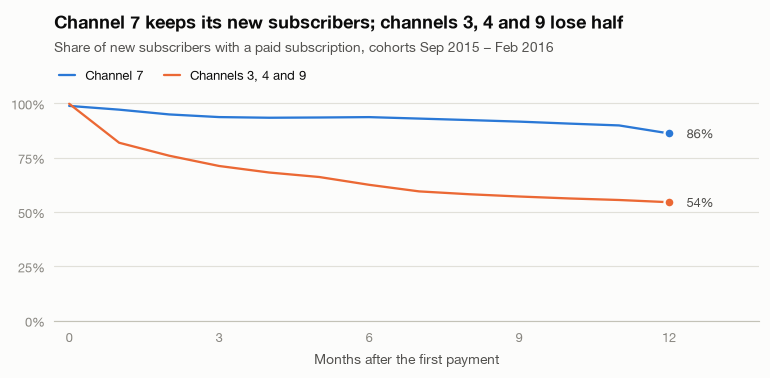

In [10]:
curve = con.sql("""
    SELECT CASE WHEN channel = 'channel 7' THEN 'Channel 7' ELSE 'Channels 3, 4 and 9' END AS grp,
           months_since_first_payment AS m,
           100 * sum(active_users) / sum(cohort_users) AS pct
    FROM marts.cohort_retention
    WHERE cohort_month BETWEEN DATE '2015-09-01' AND DATE '2016-02-01'
      AND channel IN ('channel 7', 'channel 3', 'channel 4', 'channel 9')
      AND months_since_first_payment <= 12
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
fig, ax = charts.figure(height=3.4)
ax.set_xlim(-0.3, 13.8)
ax.set_ylim(0, 105)
handles = []
for grp, color in [("Channel 7", charts.BLUE), ("Channels 3, 4 and 9", charts.ORANGE)]:
    g = curve[curve.grp == grp]
    handles.append((charts.line(ax, g.m, g.pct, color, grp), grp))
    charts.note(ax, g.m.iloc[-1] + 0.35, g.pct.iloc[-1], f"{g.pct.iloc[-1]:.0f}%")
ax.set_xticks(range(0, 13, 3))
ax.set_xlabel("Months after the first payment")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(25))
charts.legend(ax, handles)
charts.titles(fig, ax, "Channel 7 keeps its new subscribers; channels 3, 4 and 9 lose half",
              "Share of new subscribers with a paid subscription, cohorts Sep 2015 – Feb 2016")
charts.save(fig, "02_channel_retention.png")

### Is retention getting worse, or just the channel mix?

Month-3 retention of cohorts from Jul–Nov 2015 vs Jul–Nov 2016, split into the
part explained by the channel mix and the part that changed within channels.
Channel "other" is left out: it had no new users in 2015 (1.5% in 2016), so it
has no 2015 retention to compare against.

In [11]:
d = con.sql("""
    SELECT CASE WHEN cohort_month < DATE '2016-01-01' THEN 'A' ELSE 'B' END AS period,
           channel, sum(cohort_users) AS users, sum(active_users) AS active
    FROM marts.cohort_retention
    WHERE months_since_first_payment = 3 AND channel <> 'other'
      AND (cohort_month BETWEEN DATE '2015-07-01' AND DATE '2015-11-01'
           OR cohort_month BETWEEN DATE '2016-07-01' AND DATE '2016-11-01')
    GROUP BY 1, 2
""").df().pivot_table(index="channel", columns="period", values=["users", "active"], fill_value=0)
w = d["users"] / d["users"].sum()
r = d["active"] / d["users"]
overall = (w * r).sum()
mix_effect = ((w["B"] - w["A"]) * (r["A"] + r["B"]) / 2).sum()
within_effect = (((w["A"] + w["B"]) / 2) * (r["B"] - r["A"])).sum()
display(pd.DataFrame({"share_2015": 100 * w["A"], "share_2016": 100 * w["B"],
                      "m3_2015": 100 * r["A"], "m3_2016": 100 * r["B"]}).round(1))
print(f"Month-3 retention {100 * overall['A']:.1f}% -> {100 * overall['B']:.1f}% "
      f"({100 * (overall['B'] - overall['A']):+.1f} pts): channel mix {100 * mix_effect:+.1f} pts, "
      f"within channels {100 * within_effect:+.1f} pts")

,share_2015,share_2016,m3_2015,m3_2016
channel,,,,
channel 3,14.5,9.3,70.7,67.4
channel 4,7.2,29.0,71.8,69.2
channel 7,57.3,48.1,95.1,96.9
channel 9,21.0,13.6,72.0,78.2


Month-3 retention 85.0% -> 83.6% (-1.4 pts): channel mix -2.6 pts, within channels +1.2 pts


**What it says.** Channel 4 grew from nothing to 30% of new paying users, and its
users retain far worse than channel 7's. That shift alone explains the dip in
month-3 retention; within each channel, retention held or improved. Question 3
says why channel 4 looks bad: its users mostly pay manually.